In [1]:
# load data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb



In [2]:
ab = pd.read_csv(r'marketing_AB.csv')

In [3]:
# over view
ab.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
ab.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='str')

In [5]:
ab.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 32.6 MB


In [6]:
# check for null
ab.isna().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [7]:
# check test group
ab['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [9]:
ab['converted'].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

In [24]:
# check which group has most purchase

# count total size of each group
group_total= ab['test group'].value_counts()

# count true converted in each group
group_conv= ab[ab['converted']==True]['test group'].value_counts()
#calculate the conversion / sale rate on each grp
conv_rate = (group_conv/ group_total) *100
conv_rate

test group
ad     2.554656
psa    1.785411
Name: count, dtype: float64

(array([0, 1]), [Text(0, 0, 'ad'), Text(1, 0, 'psa')])

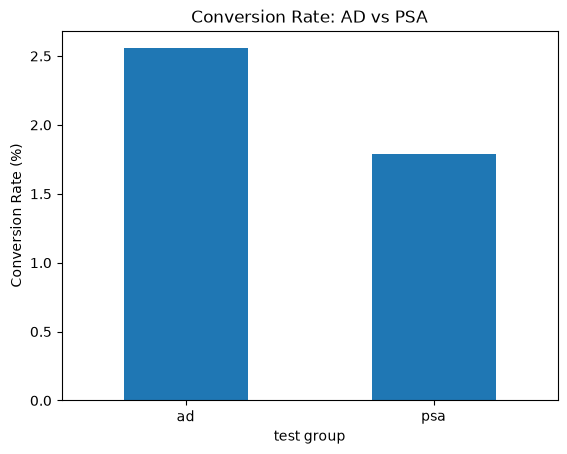

In [27]:
# graph
conv_rate.plot(kind='bar')
plt.title('Conversion Rate: AD vs PSA')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)

A/B Testing Analysis — Ad vs PSA Conversion Rate
This analysis compares the conversion rate between users who saw an advertisement ("ad" group) versus users who saw only a public service announcement ("psa" group — the control).
The ad group achieved a conversion rate of approximately 2.55%
The psa group achieved a conversion rate of approximately 1.79%
While the psa group's performance was not negligible, the ad group still outperformed it by a noticeable margin
Conclusion: Showing the advertisement had a measurable positive impact on conversions compared to the control group. This suggests the ad campaign was effective in driving purchases, justifying continued investment in advertising over relying on organic/PSA exposure alone.
(Note: Raw conversion counts were higher for the ad group primarily due to its much larger sample size — the rate comparison above gives a fairer, apples-to-apples view of performance.)

In [4]:
ab['total ads'].head()

0    130
1     93
2     21
3    355
4    276
Name: total ads, dtype: int64

In [ ]:
# check the affect on converted by total ads
ab.groupby('converted')['total ads'].mean()
# 

converted
False    23.291495
True     83.887759
Name: total ads, dtype: float64

(array([0, 1]), [Text(0, 0, 'False'), Text(1, 0, 'True')])

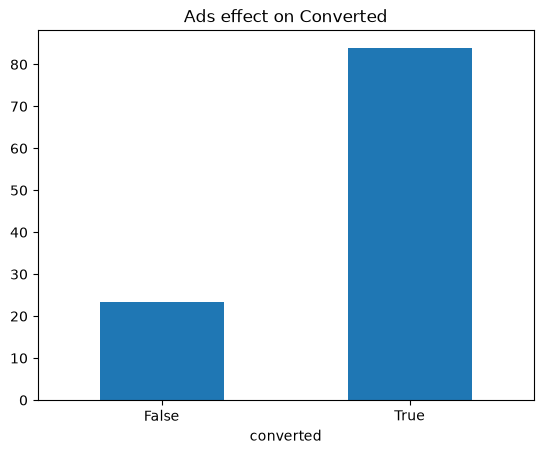

In [22]:
ab.groupby('converted')['total ads'].mean().plot(kind='bar')
plt.title('Ads effect on Converted')
plt.xticks(rotation=0)


In [14]:
# check ads result sepratly
ab.groupby(['test group','converted'])['total ads'].mean()


test group  converted
ad          False        23.274449
            True         83.905567
psa         False        23.697412
            True         83.276190
Name: total ads, dtype: float64

Text(0.5, 1.0, ' Each Ads affect on Converted ')

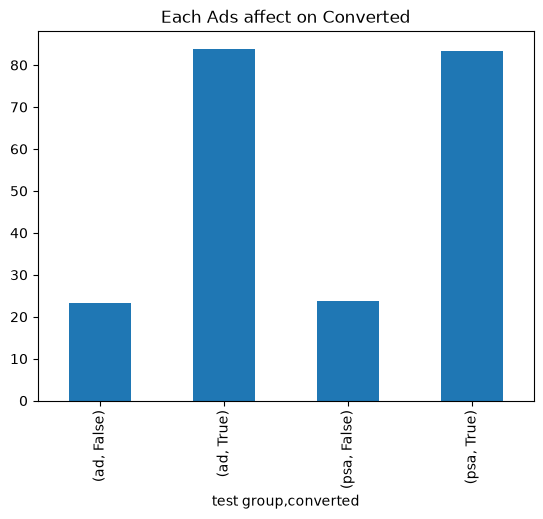

In [26]:
ab.groupby(['test group','converted'])['total ads'].mean().plot(kind='bar')
plt.title(' Each Ads affect on Converted ')


In [28]:
# check the day with most ads
ab.groupby('most ads day')['converted'].mean()

most ads day
Friday       0.022212
Monday       0.032812
Saturday     0.021051
Sunday       0.024476
Thursday     0.021571
Tuesday      0.029840
Wednesday    0.024942
Name: converted, dtype: float64

Text(0.5, 1.0, 'Most Ad Days')

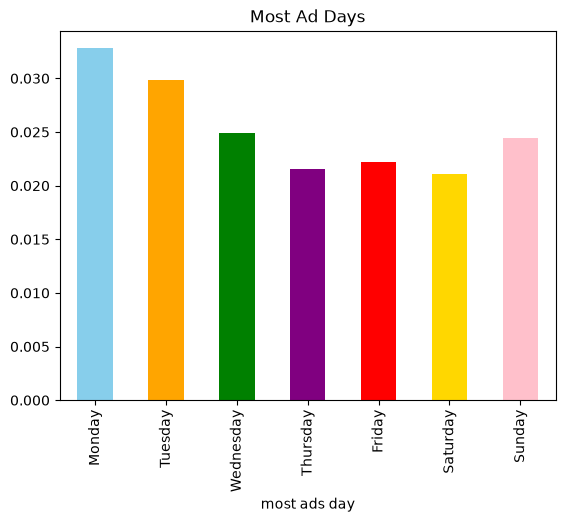

In [30]:
# graph
ab.groupby(['most ads day'])['converted'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).plot(kind='bar',color=['skyblue', 'orange', 'green', 'purple', 'red', 'gold', 'pink'])
plt.title('Most Ad Days')

In [18]:
ab.groupby(['most ads hour'])['converted'].mean()

most ads hour
0     0.018425
1     0.012911
2     0.007313
3     0.010452
4     0.015235
5     0.020915
6     0.022244
7     0.018111
8     0.019516
9     0.019191
10    0.021521
11    0.022116
12    0.023828
13    0.024677
14    0.028063
15    0.029653
16    0.030772
17    0.028210
18    0.027380
19    0.026720
20    0.029803
21    0.028923
22    0.026105
23    0.022662
Name: converted, dtype: float64

<Axes: title={'center': 'Most ads hours'}, xlabel='most ads hour'>

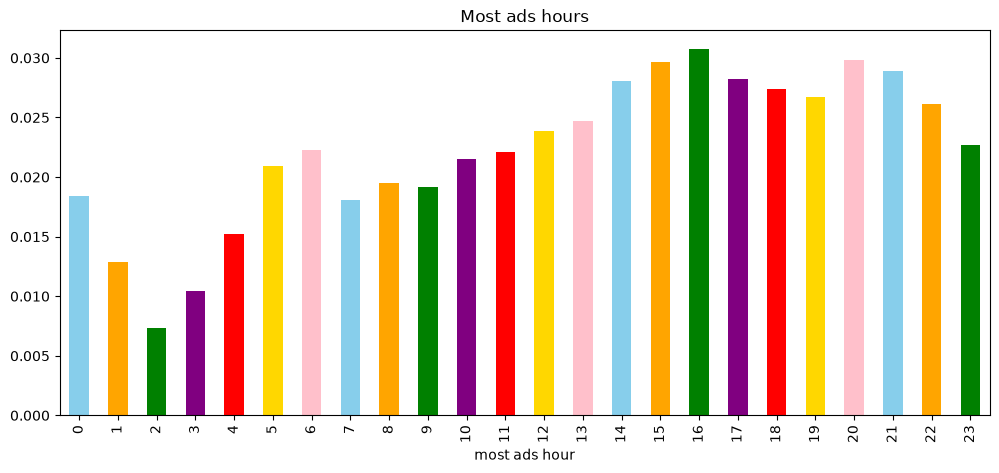

In [32]:
# chart
plt.figure(figsize=(12,5))
plt.title('Most ads hours')
ab.groupby(['most ads hour'])['converted'].mean().plot(kind='bar',color=['skyblue', 'orange', 'green', 'purple', 'red', 'gold', 'pink'])

**Ad Exposure Frequency & Conversion**
Comparing the average number of ads seen by converted vs. non-converted users, within both the Ad and PSA groups, reveals a consistent pattern:
Converted users (both in the Ad and PSA groups) were exposed to significantly more ads on average (~83–84 ads) compared to non-converted users (~23 ads)
This pattern holds true across both test groups, suggesting that repeated exposure, not just the type of content, plays a major role in driving conversions
# Day & Hour Patterns
Day & Hour Patterns
By Day: Monday shows the highest average conversion rate, followed by Tuesday — while Saturday has the lowest conversion rate among all days. This suggests users are more responsive at the start of the week.
By Hour: Conversion rates are lowest in the early hours (around hour 2), then generally trend upward through the day, peaking in the evening hours (around hour 17), before tapering off slightly late at night.
Business takeaway: Scheduling ad campaigns earlier in the week and during evening hours may lead to better conversion outcomes, based on these usage patterns.

In [61]:
# now check the distribution of total ads for each group
ab.groupby(['test group','converted'])['total ads'].mean()

test group  converted
ad          False        23.274449
            True         83.905567
psa         False        23.697412
            True         83.276190
Name: total ads, dtype: float64

<Axes: title={'center': 'Spread of total ads'}, xlabel='test group', ylabel='total ads'>

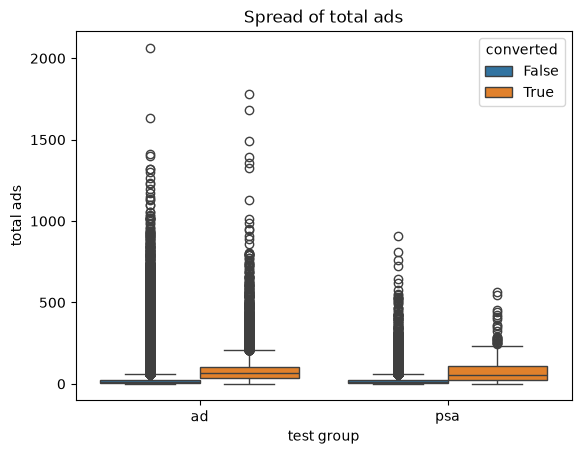

In [62]:
# graph
plt.title('Spread of total ads')

sb.boxplot(data= ab, x='test group',y='total ads',hue='converted')

In [63]:
# check the total ads by days and hours
ab.groupby(['most ads day'])['total ads'].mean()

most ads day
Friday       26.612129
Monday       25.328517
Saturday     25.227663
Sunday       24.403661
Thursday     23.428852
Tuesday      23.925464
Wednesday    24.539205
Name: total ads, dtype: float64

C:\Users\FatimaArain\AppData\Local\Temp\ipykernel_1072\2229559240.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data= ab, x= 'most ads day',y='total ads',palette='tab10')


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Friday'),
  Text(3, 0, 'Saturday'),
  Text(4, 0, 'Wednesday'),
  Text(5, 0, 'Sunday'),
  Text(6, 0, 'Thursday')])

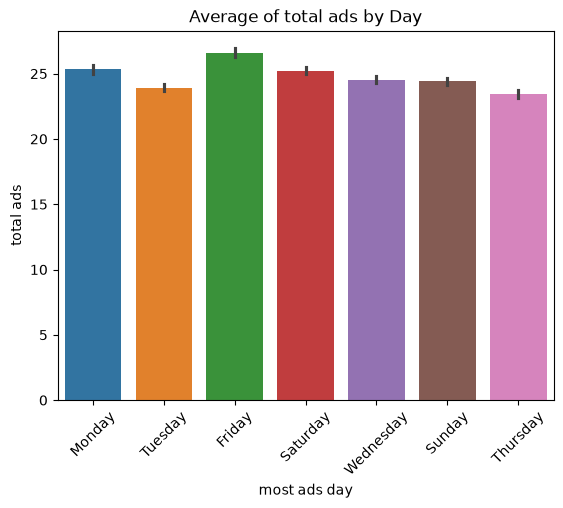

In [58]:
sb.barplot(data= ab, x= 'most ads day',y='total ads',palette='tab10')
plt.title('Average of total ads by Day')
plt.xticks(rotation=45)

In [59]:
#total ads by hour
ab.groupby(['most ads hour'])['total ads'].mean()

most ads hour
0     22.778902
1     25.179925
2     24.770111
3     22.730870
4     33.412742
5     43.648366
6     41.843327
7     31.215457
8     24.039655
9     23.486840
10    25.251727
11    24.902532
12    26.116453
13    25.593852
14    24.285533
15    25.359354
16    22.368488
17    24.250800
18    25.522600
19    25.522371
20    26.380943
21    25.555745
22    22.918205
23    20.197709
Name: total ads, dtype: float64

C:\Users\FatimaArain\AppData\Local\Temp\ipykernel_1072\1750782991.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data = ab, x='most ads hour',y='total ads',palette='tab10')


Text(0.5, 1.0, ' Most Ads hours')

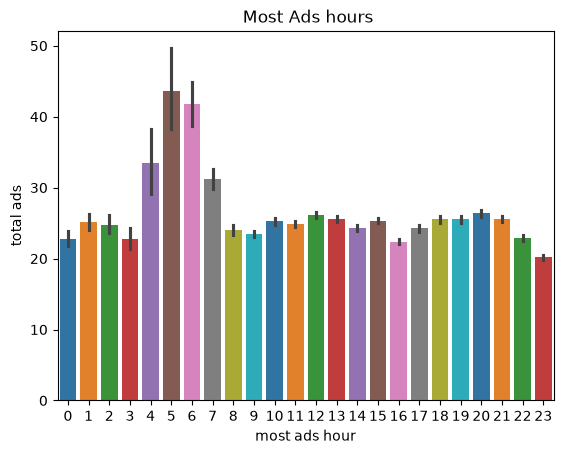

In [60]:
# graph
sb.barplot(data = ab, x='most ads hour',y='total ads',palette='tab10')
plt.title(' Most Ads hours')

**Day & Hour Patterns in Ad Exposure**
*By Day:* Friday recorded the highest average number of ads shown per user # (~26.6), closely followed by Monday and Saturday. Thursday and Tuesday saw the lowest exposure.
*By Hour:* Ad exposure peaked around hour#  5 (~43.6 average ads), followed closely by hour 6. Exposure was lowest in the early morning hours (hour 0–3) and gradually declined again later in the day.
Insight: Both the day of the week and time of day influence how many ads a user receives. Early-to-mid morning hours and end-of-week days show the highest ad delivery volume — likely reflecting when the ad platform's algorithm or campaign scheduling was most active.

**Business Analysis**

**📊 Business Analysis Summary — A/B Testing**
 # Project Overview 
This analysis compared user behavior between two groups — those shown an advertisement ("ad") and those shown a public service announcement ("psa") — to evaluate the effectiveness of the ad campaign on driving conversions.
Key Findings
**1. Conversion Rate**
The ad group achieved a conversion rate of approximately 2.55%
The psa group achieved a conversion rate of approximately 1.79%
While the psa group's performance wasn't negligible, the ad group clearly outperformed it — showing that the advertisement had a measurable positive impact on conversions.
**2. Ad Exposure Frequency**
Users who converted (converted = True) were shown significantly more ads on average (~83–84 ads) compared to users who did not convert (~23 ads).
This pattern held true in both the ad and psa groups, suggesting that repetition and frequency of exposure — not just the type of content — plays a major role in driving conversions.
**3. Day & Hour Patterns**
By day: Friday recorded the highest average ad exposure (~26.6 ads/user), closely followed by Monday and Saturday.
By hour: Ad exposure peaked around hour 5 (~43.6 ads), tapering off toward early morning and late-day hours.
###### Conclusion
Advertising drove a higher conversion rate than the control (psa) group, and frequency of exposure — how often a user saw the ad — was a stronger driver of conversion than the ad type alone. Timing also matters: exposure was heaviest early in the week and during specific hours of the day.

**Business Recommendations**
#### ✅ Continue investing in advertising 
over relying on organic/PSA-only exposure — the data shows a clear lift in conversions.
#### ✅ Prioritize repeated exposure 
— campaigns that reach users multiple times are more likely to convert them, rather than one-off impressions.
#### ✅ Schedule campaigns strategically 
— concentrate ad spend around Friday, Monday, and Saturday, and during the early-to-mid morning hours when exposure (and consequently engagement) is naturally highest.
#### ✅ Monitor outliers
 — a small number of users received unusually high ad counts (1,500–2,000+); reviewing this group could reveal diminishing returns or wasted ad spend.